<>:7: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
C:\Users\cashgen\AppData\Local\Temp\ipykernel_13036\2379348365.py:7: SyntaxWarning: invalid escape sequence '\F'
  df = pd.read_csv("C:\Files\WORK\Data Nerd\Training\Python\Project A\Playground\data_jobs.csv")
C:\Users\cashgen\AppData\Local\Temp\ipykernel_13036\2379348365.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salary_median.index, y=salary_median.values, ax=axes[1], palette=['#4b0082', '#f39c12'])


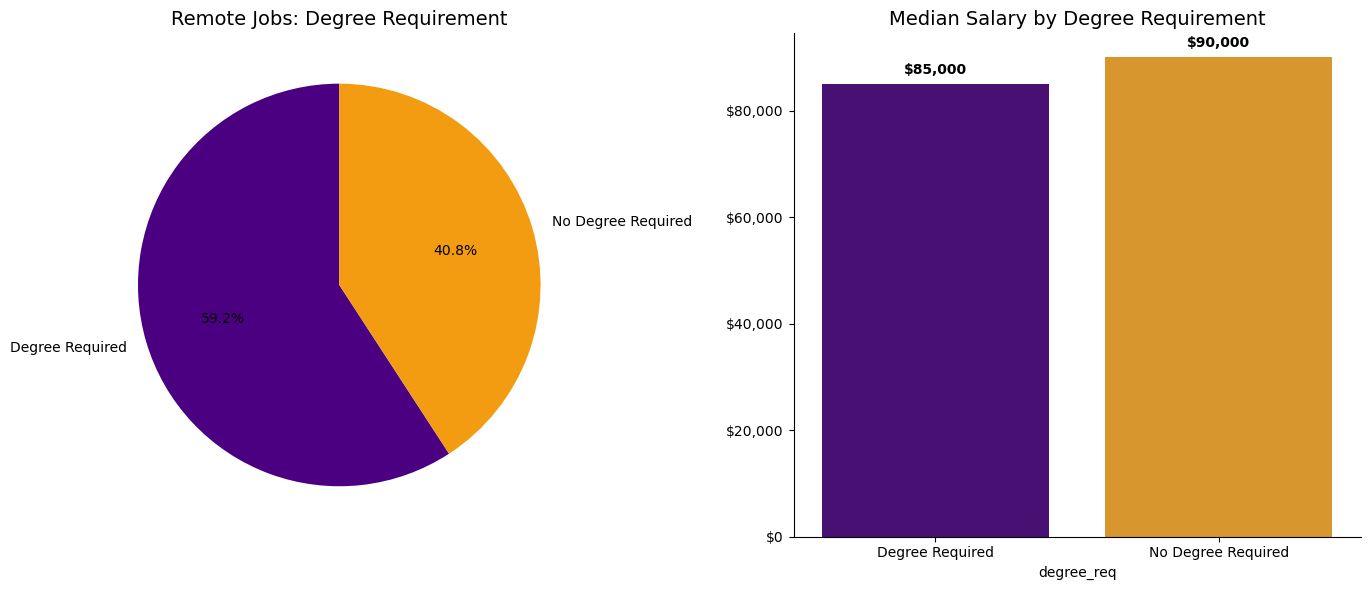

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# Load and Clean Data
df = pd.read_csv("data_jobs.csv")
df_remote = df[(df['job_title_short'] == 'Data Analyst') & (df['job_work_from_home'] == True)].copy()

df_remote['degree_req'] = df_remote['job_no_degree_mention'].map({False: 'Degree Required', True: 'No Degree Required'})

# Calculate Volume and Median Salary
volume_pct = df_remote['degree_req'].value_counts(normalize=True) * 100
df_salary = df_remote.dropna(subset=['salary_year_avg'])
salary_median = df_salary.groupby('degree_req')['salary_year_avg'].median()

# Plotting Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(volume_pct, labels=volume_pct.index, autopct='%1.1f%%', startangle=90, colors=['#4b0082', '#f39c12'])
axes[0].set_title('Remote Jobs: Degree Requirement', fontsize=14)
sns.barplot(x=salary_median.index, y=salary_median.values, ax=axes[1], palette=['#4b0082', '#f39c12'])
axes[1].set_title('Median Salary by Degree Requirement', fontsize=14)
axes[1].yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
axes[1].set_ylabel('')
for i, p in enumerate(axes[1].patches):
    axes[1].annotate(f'${int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()